In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import torch
import dnnlib.util_v5 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import gc
from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results_v5 import *
from plot_sim_results_img_v5 import * 

import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

In [2]:
def _scale_factor_like_plot(mu_traj_np, trial_indices, dims=(0,1,2), z_scale='auto'):
    # gather ranges exactly like your function
    xs, ys, zs = [], [], []
    for idx in trial_indices:
        S = mu_traj_np[idx]
        if S is None or (hasattr(S, "size") and S.size == 0):  # numpy
            continue
        A = np.asarray(S)
        xs.extend(A[:, dims[0]].tolist())
        ys.extend(A[:, dims[1]].tolist())
        zs.extend(A[:, dims[2]].tolist())
    xR = (max(xs) - min(xs)) if xs else 1.0
    yR = (max(ys) - min(ys)) if ys else 1.0
    zR = (max(zs) - min(zs)) if zs else 1.0
    if z_scale == 'auto':
        xy_avg = (xR + yR) / 2.0
        return (xy_avg / zR) if zR > 0 else 1.0
    if z_scale == 'none':
        return 1.0
    return float(z_scale)

In [3]:
def plot_selected_image(topk_idx, dset_samples_look, mean_img, h=3,
                        coords=None, row_color=None, fmt=".3f"):
    W = 2*h + 1
    idxs = torch.as_tensor(topk_idx).cpu().tolist()
    T = np.asarray(dset_samples_look[0]).shape[0]
    imgs = np.asarray(dset_samples_look[0])
    mean = np.asarray(mean_img)

    fig, axes = plt.subplots(len(idxs), W, figsize=(W*2.0, max(1, len(idxs))*2.0))
    if len(idxs) == 1:
        axes = np.expand_dims(axes, 0)

    for r, i in enumerate(idxs):
        cols_ts = list(range(i - h, i + h + 1))
        for c, t in enumerate(cols_ts):
            ax = axes[r, c]
            if 0 <= t < T:
                ax.imshow(imgs[t, 0] + mean, cmap='gray')
                rel = t - i
                if rel == 0:
                    # center frame title
                    if coords is not None and i in coords:
                        u1, u2, u3 = coords[i]
                        ttl = f"t={t}\n[μ1={u1:{fmt}}, μ2={u2:{fmt}}, μ3={u3:{fmt}}]"
                        ax.set_title(ttl, fontsize=12,
                                     color=(row_color if row_color is not None else 'k'),
                                     fontweight='bold')
                    else:
                        ax.set_title(f"t={t}", fontsize=12)
                else:
                    ax.set_title(f"t+{rel}" if rel > 0 else f"t{rel}", fontsize=10)
            ax.axis("off")
    plt.tight_layout()

In [4]:
def plot_frame(data, T, trial_idx, mean_img = None):
    idxs = np.linspace(0, T-1, 6, dtype=int)
    fig, axes = plt.subplots(1, len(idxs), figsize=(12, 2))
    for ax, i in zip(axes, idxs):
        if mean_img is None:
            ax.imshow(data[trial_idx][i,0,:,:], cmap = 'gray')
        else:
            ax.imshow(data[trial_idx][i,0,:,:] + mean_img, cmap = 'gray')
        ax.set_title(f"t={i}")
        ax.axis("off")
    plt.tight_layout()
    # plt.show()

In [5]:
def mu2_bands_from_hist(y, m=3, bins=80, smooth=5):
    y_np = y.detach().cpu().numpy()
    cnt, edges = np.histogram(y_np, bins=bins)
    # gentle smoothing
    if smooth > 0:
        ker = np.array([1,2,3,2,1], float)
        ker /= ker.sum()
        for _ in range(smooth): cnt = np.convolve(cnt, ker, mode='same')
    centers = (edges[:-1] + edges[1:]) / 2

    # peaks
    pk = np.where((cnt[1:-1] > cnt[:-2]) & (cnt[1:-1] >= cnt[2:]))[0] + 1
    if pk.size == 0: pk = np.array([cnt.argmax()])
    pk = sorted(pk, key=lambda i: cnt[i], reverse=True)[:m]
    pk.sort()  # low → high

    # boundaries: minima between consecutive peaks
    bounds = [-np.inf]
    for a,b in zip(pk[:-1], pk[1:]):
        valley = a + np.argmin(cnt[a:b+1])
        boundary = centers[valley]
        bounds.append(boundary)
    bounds.append(np.inf)

    # label each point
    labels = np.zeros_like(y_np, dtype=int)
    for bi in range(m):
        mask = (y_np > bounds[bi]) & (y_np <= bounds[bi+1])
        labels[mask] = bi
    return torch.from_numpy(labels).to(y.device), torch.from_numpy(centers[pk]).to(y.device)

def reps_for_band(band_id, k, z_keep_q_seq=(0.20, 0.30, 0.50, 0.75, 1.00)):
    idx_all = torch.nonzero(band == band_id, as_tuple=False).squeeze(1)
    if idx_all.numel() == 0:
        return []

    # --- 1) ON-BAND in μ3 (use plotted z = mu3) ---
    z = mu3[idx_all]
    z_med = z.median()
    z_dev = (z - z_med).abs()

    cand = None
    for q in z_keep_q_seq:                          # progressively widen if too tight
        thr = torch.quantile(z_dev, q)
        cand = idx_all[z_dev <= thr]
        if cand.numel() >= min(k, idx_all.numel()):
            break
    if cand is None or cand.numel() == 0:
        order = torch.argsort(z_dev)
        return idx_all[order[:min(k, idx_all.numel())]].cpu().tolist()

    # --- 2) Spread along μ1 inside this band (greedy farthest-point) ---
    x = mu1[cand]
    if cand.numel() <= k:
        return cand.cpu().tolist()

    # seed: closest to μ1 median (stable)
    seed_rel = (x - x.median()).abs().argmin()
    chosen_abs = [int(cand[seed_rel].item())]

    # remaining pool
    mask = torch.ones(cand.numel(), dtype=torch.bool, device=cand.device)
    mask[seed_rel] = False
    remaining = cand[mask]
    if remaining.numel() == 0:
        return chosen_abs

    # track min |Δμ1| to chosen set
    min_dist = (mu1[remaining] - mu1[chosen_abs[0]]).abs()
    while len(chosen_abs) < k and remaining.numel() > 0:
        j_rel = torch.argmax(min_dist)
        j_abs = int(remaining[j_rel].item())
        chosen_abs.append(j_abs)

        if remaining.numel() == 1:
            break
        keep = torch.arange(remaining.numel(), device=remaining.device) != j_rel
        remaining = remaining[keep]
        if remaining.numel() == 0:
            break
        new_d = (mu1[remaining] - mu1[j_abs]).abs()
        min_dist = torch.minimum(min_dist[keep], new_d)

    return chosen_abs

In [6]:
def band_mu1_range(b, qlo=0.10, qhi=0.90):
    idx = torch.nonzero(band == b, as_tuple=False).squeeze(1)
    if idx.numel() == 0:
        return None
    lo = torch.quantile(mu1[idx], qlo)
    hi = torch.quantile(mu1[idx], qhi)
    return lo, hi

# 2. read data

In [7]:
# folder_data = '/hpc/group/pearsonlab/gw74/musal_output/dim3_lag5/t/data'
# folder = '/hpc/group/pearsonlab/gw74/musal_output/dim3_lag5/t/00004-musal_dim3_lag5_t-prr-uncond-regularFM-gpus4-batch256-fp32'
# chk_pts = '/network-snapshot-070246.pkl' # '/network-snapshot-210739.pkl'

# folder_data = '/hpc/group/pearsonlab/gw74/musal_output/dim3_lag5/t_noise/data'
# folder = '/hpc/group/pearsonlab/gw74/musal_output/dim3_lag5/t_noise/00003-musal_dim3_lag5_t-prr-uncond-regularFM-gpus4-batch256-fp32'
# chk_pts = '/network-snapshot-110386.pkl' # '/network-snapshot-210739.pkl'

folder_data = '/hpc/group/pearsonlab/gw74/widefield_output/dim3_lag5/t_noise/data'
folder = '/hpc/group/pearsonlab/gw74/widefield_output/dim3_lag5/t_noise/00001-widefield_dim3_lag5_t-prr-uncond-regularFM-gpus4-batch256-fp32'
chk_pts = '/network-snapshot-065229.pkl' # '/network-snapshot-210739.pkl'


useCov = False

dim_to_keep = 3

In [8]:
pkl_path = folder + chk_pts

In [9]:
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)

In [10]:
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])
# mean_img = np.load('data/musal_behavior/mean_image.npy')

In [11]:
dset_samples[0].shape

(200, 1, 64, 64)

In [12]:
# # no clamp
# clamp_range = None

# # version 1: global clamp (results are similar)
# eps = 1e-2
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value - eps, max_value + eps], dtype=np.float32) # give some space

# version 2: clamp dim-by-dim (results are similar)
eps = 1e-2
T_max = max(a.shape[0] for a in dset_samples)
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

# 3. read model

In [13]:
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)
if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else: net = model_all['net']  # Raw trained model
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder

In [14]:
lag = infer_lag_k_from_dyn_net(dyn_net)

# 4. Projected latent

In [40]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)
# n_step = T_max
# dset_samples_look = [dset_samples[0][:n_step]]
dset_samples_look = dset_samples

In [51]:
len(dset_samples_look)

316

In [41]:
gc.collect()
torch.cuda.empty_cache()
latent_traj_list = proj_to_latent(dset_samples_look, flow_net.to(device), 0.0, device, chunk_size = 1024)
gc.collect()
torch.cuda.empty_cache()

In [46]:
mu_traj_sim, d, L, loading = latent_mu(latent_traj_list, encoder.to(device), dim_to_keep, device, fullRes = True)

In [47]:
d[0:10]

tensor([4.8358e-02, 3.8107e-02, 2.5586e-04, 6.6888e-13, 6.6198e-13, 1.6707e-12,
        5.0695e-13, 5.0706e-13, 5.1768e-13, 7.1557e-13], device='cuda:0')

Text(0.5, 0.98, 'flowed latent trajc for each trial')

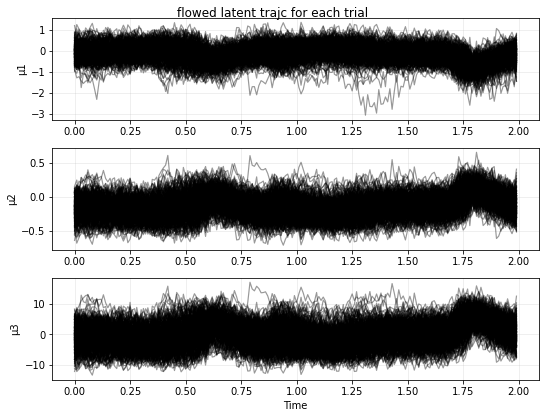

In [48]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
plot_latent_time_series(mu_traj_sim_np, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('flowed latent trajc for each trial')

## 4.2 2D?

(<Figure size 432x432 with 2 Axes>,
 <Axes: title={'center': 'Flowed Latent trajectories'}, xlabel='μ1', ylabel='μ2'>)

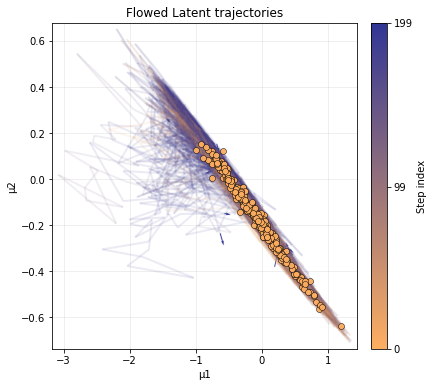

In [53]:
plot_mu_trajectories_gradient_steps_2d(
    mu_traj_sim_np,
    trial_indices=np.arange(len(mu_traj_sim_np)), 
    dims=(0,1),
    alpha = 0.1,
    title="Flowed Latent trajectories",
)

## 4.2 3D?

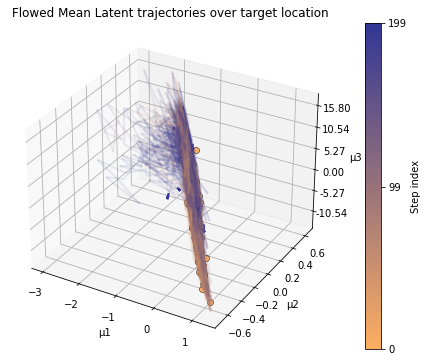

In [50]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_sim,
    labels=None,
    trial_indices=np.arange(len(mu_traj_sim)), 
    dims=(0,1,2),
    alpha=0.1,
    title="Flowed Mean Latent trajectories over target location",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)